## SUSAN Corner Detection + Convex Hull Thresholding

In [276]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### Helper Functions to Avoid Using the pre defined functions

In [277]:
def manual_append(mask_list, element):
    new_list = [0] * (len(mask_list) + 1)
    for i in range(len(mask_list)):
        new_list[i] = mask_list[i]
    new_list[len(mask_list)] = element
    return new_list

In [278]:
def manual_min(arr):
    flat_arr = arr.flatten()
    min_val = flat_arr[0]
    for i in range(1, len(flat_arr)):
        if flat_arr[i] < min_val:
            min_val = flat_arr[i]
    return min_val

In [279]:
def manual_max(arr):
    flat_arr = arr.flatten()
    max_val = flat_arr[0]
    for i in range(1, len(flat_arr)):
        if flat_arr[i] > max_val:
            max_val = flat_arr[i]
    return max_val

In [280]:
def manual_argmax(array):
    max_val = array[0]
    max_idx = 0
    for i in range(1, len(array)):
        if array[i] > max_val:
            max_val = array[i]
            max_idx = i
    return max_idx

### 1. SUSAN Implementation

In [281]:
def circular_mask(radius):
    mask = []
    for a in range(-radius, radius + 1):
        for b in range(-radius, radius + 1): 
            mask = manual_append(mask, (b, a))
    return mask

In [282]:
def susan(image, t, radius=1):
    h, w = image.shape
    img = image.astype(np.float32)
    mask = circular_mask(radius)
    scores = np.zeros((h, w), dtype=np.float32)
    hist = np.zeros(10, dtype=np.int32)
    for y in range(h):
        for x in range(w):
            center_intensity = img[y, x]
            usan_size = 0.0
            for b, a in mask:
                ny = y + a
                nx = x + b
                if 0 <= ny < h and 0 <= nx < w:
                    neighbor_intensity = img[ny, nx]
                    intensity_diff = neighbor_intensity - center_intensity
                    c_m = np.exp(-((intensity_diff / t) ** 6))
                    usan_size += c_m
            scores[y, x] = int(np.floor(usan_size))
            hist[int(np.floor(scores[y, x]))] += 1
    return scores, hist

### 2. Convex Hull Implementation + Two Pass Threshold Implementation

#### 2.a Convex Hull Implementation

In [283]:
def CalculateHullPoints(histogram):
    n = len(histogram)
    hull_points = []
    i = 0
    while i < n - 1:
        max_slope = -np.inf
        best_j = i + 1
        for j in range(i + 1, n):  
            slope = (histogram[j] - histogram[i]) / (j - i)
            if slope > max_slope:
                max_slope = slope
                best_j = j
        hull_points.append((i, histogram[i]))
        i = best_j 
        if i >= n - 1:
            break
    if not hull_points or hull_points[-1][0] != n - 1:
        hull_points.append((n - 1, histogram[n - 1]))
    return hull_points

In [284]:
def GetHullValues(hull_points):
    if len(hull_points) == 0:
        return np.array([])
    last_idx = hull_points[-1][0]
    hull_values = np.zeros(last_idx + 1, dtype=np.float32)
    for i in range(len(hull_points) - 1):
        x1, y1 = hull_points[i]
        x2, y2 = hull_points[i + 1]
        delta_x = x2 - x1
        if delta_x == 0:
            hull_values[x1] = y1
        else:
            delta_y = y2 - y1
            step_value = delta_y / delta_x
            for j in range(delta_x + 1):
                idx = x1 + j
                hull_values[idx] = y1 + (step_value * j)
    return hull_values

In [285]:
def GetThreshold(histogram, hull_values):
    differences = hull_values - histogram
    threshold_idx = manual_argmax(differences)
    return threshold_idx

In [286]:
def ApplyThresh(histogram, threshold_idx):
    below_thresh = histogram[:threshold_idx + 1]  
    above_thresh = histogram[threshold_idx + 1:]  
    print("below", below_thresh)
    print("above", above_thresh)
    return below_thresh, above_thresh

#### 2.b Two Pass Threshold Implementation

In [287]:
def two_pass_convex_hull_threshold(histogram):
    hull_points_1 = CalculateHullPoints(histogram)
    hull_values_1 = GetHullValues(hull_points_1)
    threshold1 = GetThreshold(histogram, hull_values_1)
    below_t1, above_t1 = ApplyThresh(histogram, threshold1)
    hull_points_2 = CalculateHullPoints(below_t1)
    hull_values_2 = GetHullValues(hull_points_2)
    threshold2 = GetThreshold(below_t1, hull_values_2)
    return threshold1, threshold2

### 3. Draw Image


In [288]:
def DrawImages(threshold1, threshold2, susan_image):
    corners = np.zeros_like(susan_image)
    edges = np.zeros_like(susan_image)
    hemo = np.zeros_like(susan_image)
    for i in range(susan_image.shape[0]):
        for j in range(susan_image.shape[1]):
            pixel_value = susan_image[i, j]
            if pixel_value <= threshold2:
                corners[i, j] = pixel_value
            elif threshold2 < pixel_value <= threshold1:
                edges[i, j] = pixel_value
            else:
                hemo[i, j] = pixel_value
    return corners, edges, hemo

#### For Visualization 

In [289]:
def plot_comprehensive_results(original, susan_response, histogram, 
                               t1, t2, corners, edges, homogeneous, t_parameter):
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f't={t_parameter}: SUSAN Corner Detection Results', fontsize=16, fontweight='bold')
    plt.subplot(3, 4, 1)
    plt.imshow(original, cmap='gray')
    plt.title('1. Original Image', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.subplot(3, 4, 2)
    plt.imshow(susan_response, cmap='gray')
    plt.title('2. SUSAN Response', fontsize=14, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.subplot(3, 4, 3)
    x = np.arange(len(histogram))
    plt.plot(x, histogram, 'b-', linewidth=2)
    plt.axvline(t1, color='r', linestyle='--', linewidth=2, label=f'T1={t1}')
    plt.axvline(t2, color='g', linestyle='--', linewidth=2, label=f'T2={t2}')
    plt.title('3. Histogram + Thresholds', fontsize=14, fontweight='bold')
    plt.xlabel('Intensity')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.subplot(3, 4, 5)
    plt.imshow(corners, cmap='gray')
    plt.title(f'5. CORNERS\n(≤ {t2})', fontsize=14, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.subplot(3, 4, 6)
    plt.imshow(edges, cmap='gray')
    plt.title(f'6. EDGES\n({t2} < x ≤ {t1})', fontsize=14, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.subplot(3, 4, 7)
    plt.imshow(homogeneous, cmap='gray')
    plt.title(f'7. HOMOGENEOUS\n(> {t1})', fontsize=14, fontweight='bold')
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis('off')
    plt.tight_layout()
    return fig

#### The Complete pipeline

In [290]:
def run_complete_pipeline(image_path, t_parameter=27, radius=1):
    print(f"\nLoading image: {image_path}")
    image = Image.open(image_path)
    gray_image = np.array(image.convert('L'))  
    susan_response, histogram = susan(gray_image, t=t_parameter, radius=radius)
    threshold1_idx, threshold2_idx = two_pass_convex_hull_threshold(histogram)
    corners, edges, homogeneous = DrawImages(threshold1_idx, threshold2_idx, susan_response)
    fig = plot_comprehensive_results(
        gray_image, susan_response, histogram,
        threshold1_idx, threshold2_idx, 
        corners, edges, homogeneous, t_parameter
    )
    print("\nProcessing complete!")
    print("="*80)
    return {
        'susan_response': susan_response,
        'histogram': histogram,
        'threshold1_idx': threshold1_idx,
        'threshold2_idx': threshold2_idx
    }


Loading image: Test Image.png
below [    0 11485 32115 35686 30799 59757 37616 31602]
above [152193   1963]

Processing complete!


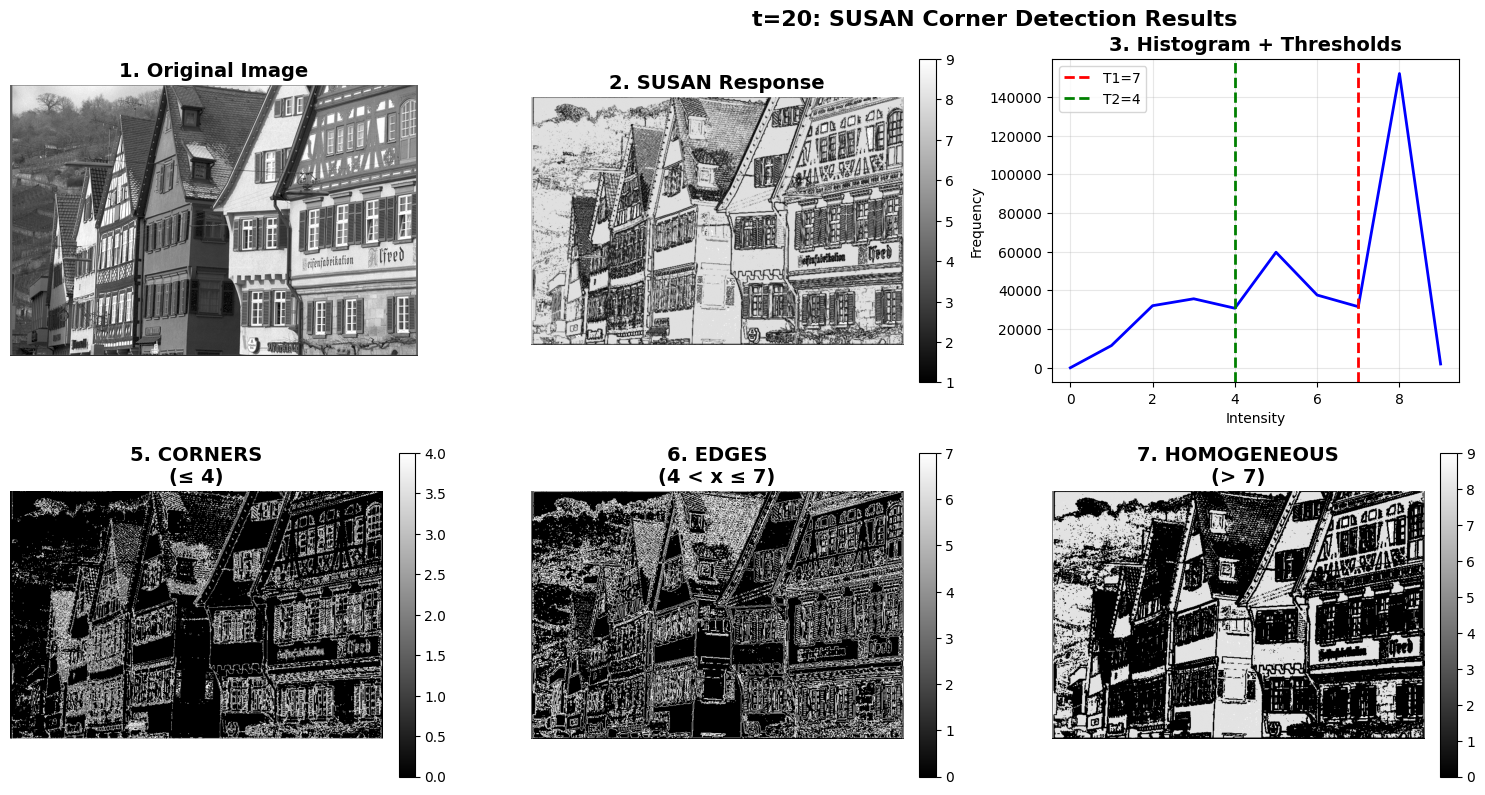

In [291]:
image_path1 = 'Test Image.png'
run = run_complete_pipeline(image_path1, t_parameter=20, radius=1)



Loading image: test11.jpg
below [   0    0    0    4    4   55 4932    5  212]
above [308352]

Processing complete!


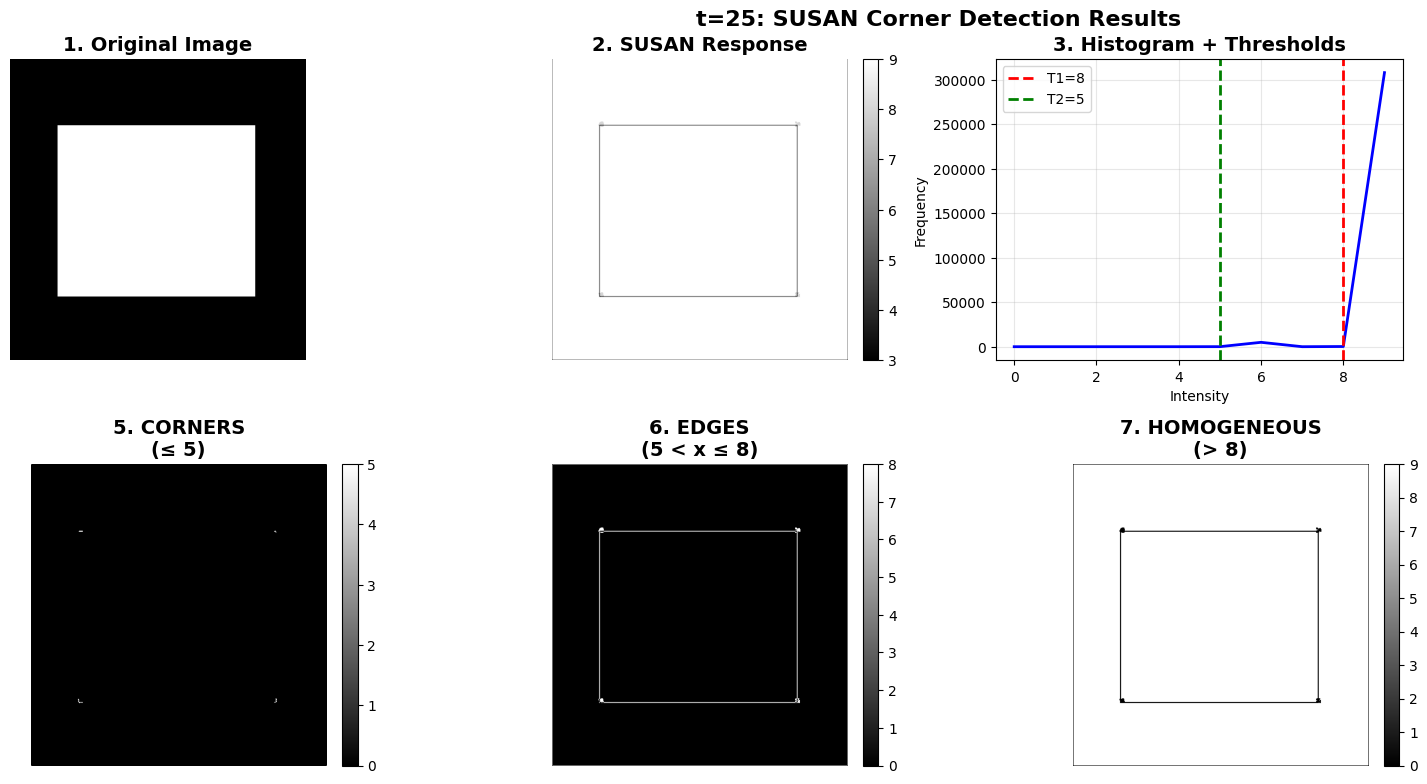

In [292]:
image_path1 = 'test11.jpg'
run = run_complete_pipeline(image_path1, t_parameter=25, radius=1)


Loading image: test2.png
below [    0   736  2690  4934  6439 12541 12820 12833]
above [74401 35461]

Processing complete!


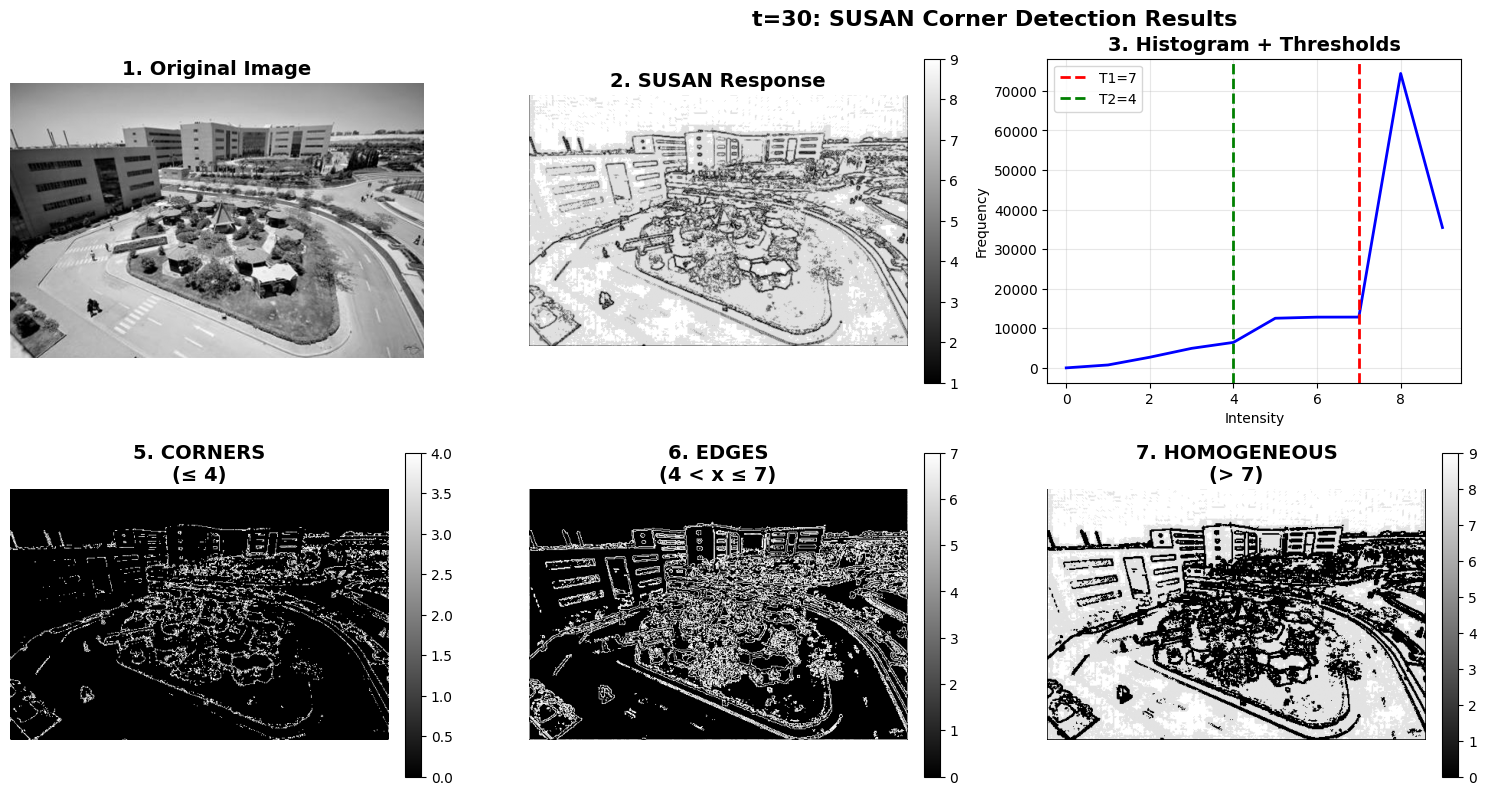

In [293]:
image_path1 = 'test2.png'
run = run_complete_pipeline(image_path1, t_parameter=30, radius=1)